# More Objectives Example

Replicates analysis for increasing number of objectives using packaged functions.

In [1]:
from graphallocbench.evaluation import (
    run_experiments,
    plot_more_objectives,
)
from graphallocbench.city_env.env_model import CityPlannerEnv
import numpy as np

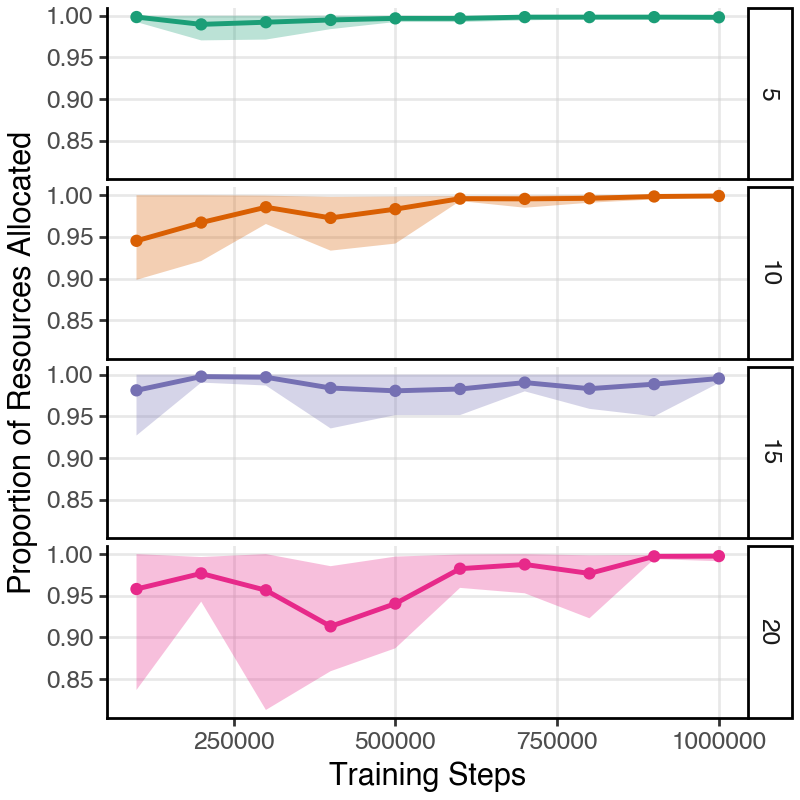

In [2]:
def calculate_sparse_metrics(env: CityPlannerEnv, model=None, seed=42):
    objectives, _ = run_experiments(env=env, model=model, n_iter=100, random_seed=seed)
    distances = np.linalg.norm(objectives, axis=1)
    avg_dist = np.mean(distances)
    std_dev = np.std(distances)
    ideal_dist = np.sqrt(10 + env.n_objectives)
    distance_ratio = avg_dist / ideal_dist
    non_dominated = np.count_nonzero(np.isclose(distances, ideal_dist)) / objectives.shape[0]
    return {
        'distance_ratio': distance_ratio,
        'non_dominated': non_dominated,
    }

plot_more_objectives(problem='logistic_long', project_name='MoreObjectives', total_steps=1000000)